
GRADIENT DESCENT ALGORITHM

Problem: minimize f(x)

Algorithm:
  1. Choose starting point x₀
  2. Choose step size α > 0 (learning rate)
  3. For k = 0, 1, 2, ... until convergence:
       • Compute gradient: g = ∇f(xₖ)
       • Update: xₖ₊₁ = xₖ - α·g
       • Check: if ||g|| < ε, stop (converged)

Key Intuition:
  • Gradient ∇f(x) points in direction of STEEPEST ASCENT
  • We want to MINIMIZE, so move in OPPOSITE direction: -∇f(x)
  • Step size α controls how far we move
  • We take small steps downhill until we reach the bottom

Step Size (Learning Rate) α:
  • Too small: convergence is very slow (many iterations)
  • Just right: fast convergence
  • Too large: oscillation, zigzagging
  • Way too large: divergence (algorithm fails)

Convergence for Convex Functions:
  • Guaranteed to reach global minimum
  • With constant step size:
    - Need α < 2/L where L is Lipschitz constant of ∇f
    - Convergence rate: O(1/k) where k is iteration number
  • With line search: can adapt α at 

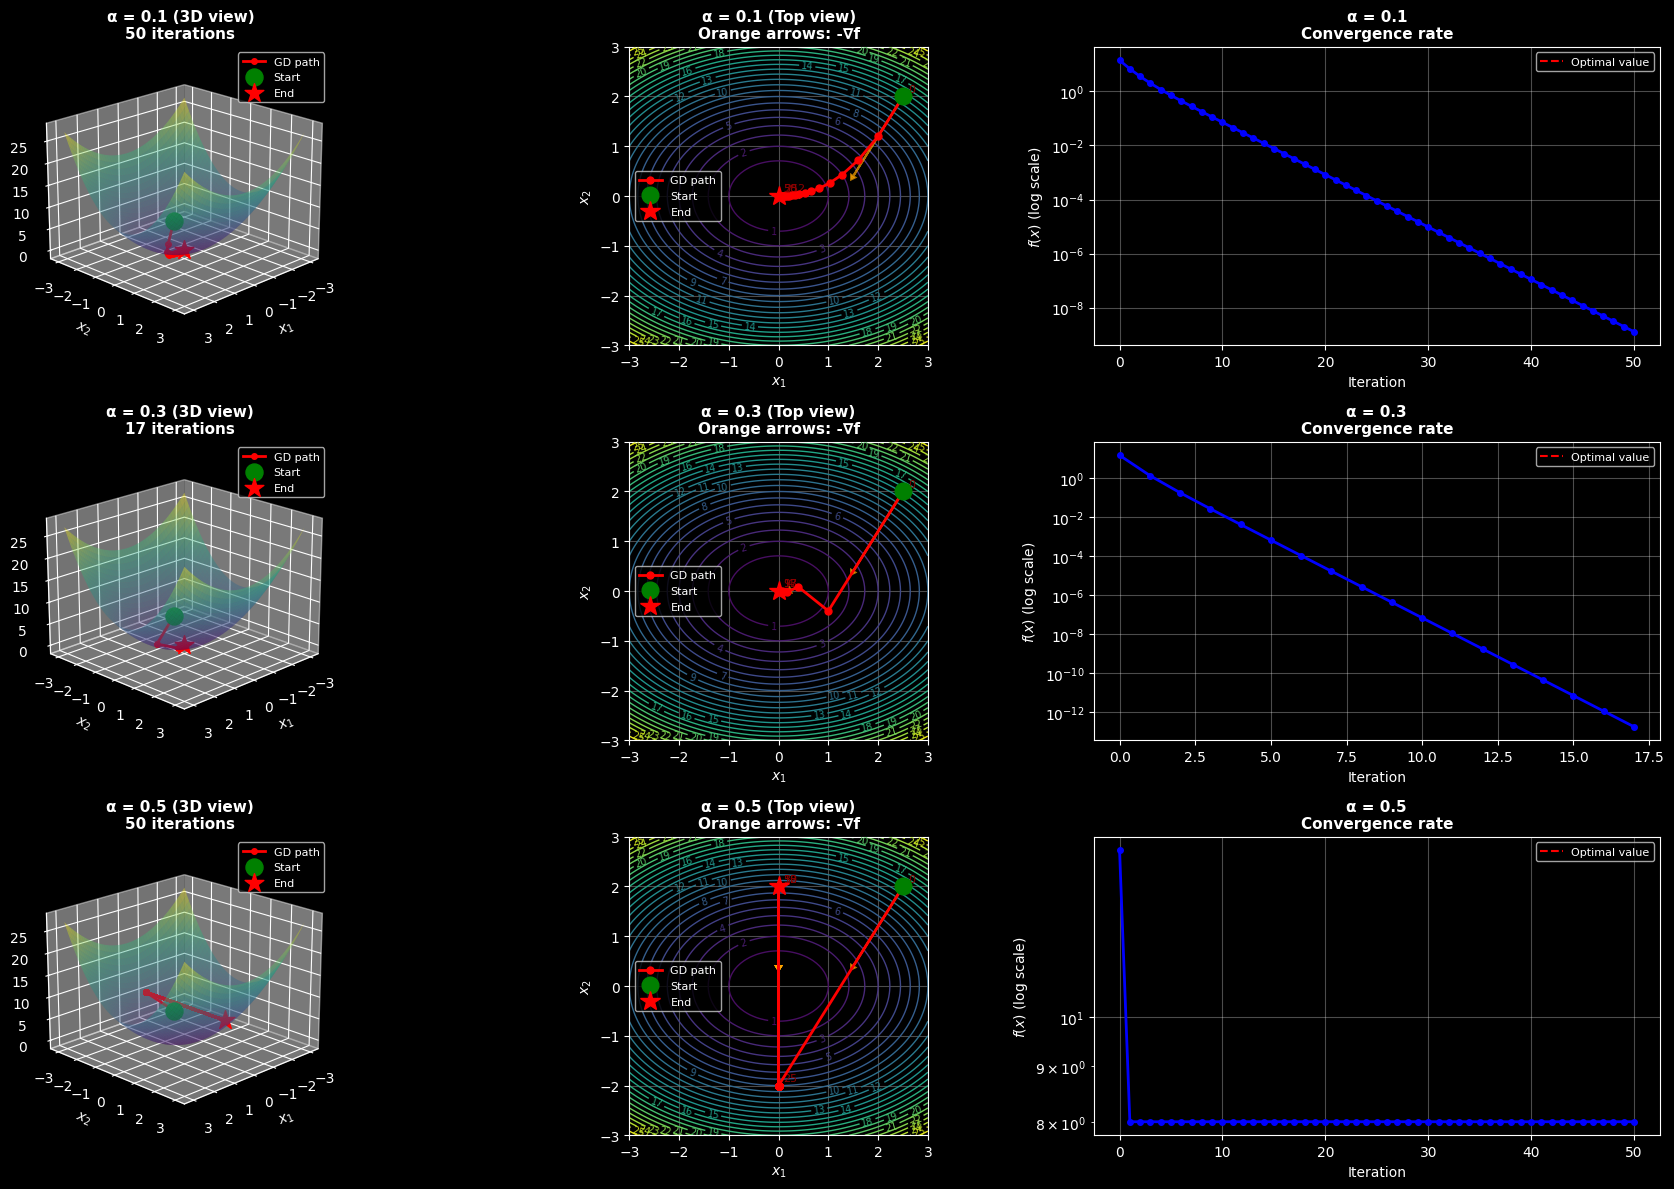



Demonstrating step size effects...

Converged in 18 iterations


/var/folders/bm/v89_1zhd4ln63tpghxb09nyw0000gn/T/ipykernel_24268/2106136697.py:235: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()



SUMMARY

Gradient Descent in a nutshell:
  xₖ₊₁ = xₖ - α∇f(xₖ)

Think of it as:
  'Stand on a hill, look which way is steepest down,
   take a step in that direction, repeat until at the bottom'

Compare to Interior Point Method:
  • GD: First-order (uses only gradient)
  • IPM: Second-order (uses Hessian, like Newton)
  • GD: Many cheap iterations
  • IPM: Few expensive iterations
  • GD: Great for unconstrained, huge problems
  • IPM: Great for constrained, medium problems


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

def gradient_descent(f, grad_f, x0, alpha, max_iter=100, tol=1e-6):
    """
    Gradient descent algorithm
    
    Parameters:
    - f: objective function
    - grad_f: gradient of f
    - x0: starting point
    - alpha: step size (learning rate)
    - max_iter: maximum iterations
    - tol: tolerance for stopping
    
    Returns:
    - path: array of points visited
    - values: function values at each point
    """
    path = [x0.copy()]
    values = [f(x0)]
    x = x0.copy()
    
    for i in range(max_iter):
        grad = grad_f(x)
        
        # Check if gradient is small enough (converged)
        if np.linalg.norm(grad) < tol:
            print(f"Converged in {i+1} iterations")
            break
        
        # Gradient descent update: x_new = x - alpha * gradient
        x_new = x - alpha * grad
        
        path.append(x_new.copy())
        values.append(f(x_new))
        x = x_new
    
    return np.array(path), np.array(values)

def visualize_gradient_descent_2d():
    """
    Visualize gradient descent on a 2D function
    """
    # Define objective function: f(x1, x2) = x1² + 2*x2²
    def f(x):
        return x[0]**2 + 2*x[1]**2
    
    # Gradient: ∇f = [2*x1, 4*x2]
    def grad_f(x):
        return np.array([2*x[0], 4*x[1]])
    
    # Create grid for visualization
    x1 = np.linspace(-3, 3, 100)
    x2 = np.linspace(-3, 3, 100)
    X1, X2 = np.meshgrid(x1, x2)
    Z = X1**2 + 2*X2**2
    
    # Starting point
    x0 = np.array([2.5, 2.0])
    
    # Run gradient descent with different step sizes
    alpha_values = [0.1, 0.3, 0.5]
    
    fig = plt.figure(figsize=(18, 12))
    
    for idx, alpha in enumerate(alpha_values):
        print(f"\n{'='*60}")
        print(f"Running gradient descent with α = {alpha}")
        print(f"{'='*60}")
        
        path, values = gradient_descent(f, grad_f, x0, alpha, max_iter=50)
        
        print(f"Starting point: ({x0[0]:.2f}, {x0[1]:.2f}), f = {f(x0):.4f}")
        print(f"Final point: ({path[-1][0]:.4f}, {path[-1][1]:.4f}), f = {values[-1]:.6f}")
        print(f"Number of iterations: {len(path)-1}")
        
        # ========== 3D Plot ==========
        ax1 = fig.add_subplot(3, 3, idx*3 + 1, projection='3d')
        
        # Surface
        surf = ax1.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.4, 
                               edgecolor='none', antialiased=True)
        
        # Plot the path
        z_path = np.array([f(p) for p in path])
        ax1.plot(path[:, 0], path[:, 1], z_path, 'ro-', linewidth=2, 
                markersize=4, label='GD path')
        
        # Mark start and end
        ax1.scatter([x0[0]], [x0[1]], [f(x0)], color='green', s=150, 
                   marker='o', zorder=10, label='Start')
        ax1.scatter([path[-1, 0]], [path[-1, 1]], [z_path[-1]], color='red', 
                   s=200, marker='*', zorder=10, label='End')
        
        ax1.set_xlabel('$x_1$', fontsize=10)
        ax1.set_ylabel('$x_2$', fontsize=10)
        ax1.set_zlabel('$f(x_1, x_2)$', fontsize=10)
        ax1.set_title(f'α = {alpha} (3D view)\n{len(path)-1} iterations', 
                     fontsize=11, fontweight='bold')
        ax1.legend(fontsize=8)
        ax1.view_init(elev=20, azim=45)
        
        # ========== Contour Plot ==========
        ax2 = fig.add_subplot(3, 3, idx*3 + 2)
        
        contour = ax2.contour(X1, X2, Z, levels=30, cmap='viridis', linewidths=1)
        ax2.clabel(contour, inline=True, fontsize=7)
        
        # Plot the path
        ax2.plot(path[:, 0], path[:, 1], 'ro-', linewidth=2, markersize=5, 
                label='GD path', zorder=5)
        
        # Draw gradient arrows at some points
        step = max(1, len(path) // 8)
        for i in range(0, len(path)-1, step):
            pt = path[i]
            grad = grad_f(pt)
            grad_norm = np.linalg.norm(grad)
            if grad_norm > 0.01:
                scale = 0.2
                ax2.arrow(pt[0], pt[1], -grad[0]*scale, -grad[1]*scale,
                         head_width=0.1, head_length=0.08, fc='orange', 
                         ec='orange', linewidth=1.5, alpha=0.7, zorder=4)
        
        # Mark points
        ax2.plot(x0[0], x0[1], 'go', markersize=12, label='Start', zorder=6)
        ax2.plot(path[-1, 0], path[-1, 1], 'r*', markersize=15, 
                label='End', zorder=6)
        
        # Number some iterations
        for i in [0, len(path)//4, len(path)//2, 3*len(path)//4, len(path)-1]:
            if i < len(path):
                ax2.text(path[i, 0]+0.1, path[i, 1]+0.1, str(i), 
                        fontsize=8, color='darkred')
        
        ax2.set_xlabel('$x_1$', fontsize=10)
        ax2.set_ylabel('$x_2$', fontsize=10)
        ax2.set_title(f'α = {alpha} (Top view)\nOrange arrows: -∇f', 
                     fontsize=11, fontweight='bold')
        ax2.grid(True, alpha=0.3)
        ax2.set_aspect('equal')
        ax2.legend(fontsize=8)
        
        # ========== Convergence Plot ==========
        ax3 = fig.add_subplot(3, 3, idx*3 + 3)
        
        iterations = np.arange(len(values))
        ax3.semilogy(iterations, values, 'b-o', markersize=4, linewidth=2)
        ax3.axhline(0, color='red', linestyle='--', linewidth=1.5, 
                   label='Optimal value')
        
        ax3.set_xlabel('Iteration', fontsize=10)
        ax3.set_ylabel('$f(x)$ (log scale)', fontsize=10)
        ax3.set_title(f'α = {alpha}\nConvergence rate', 
                     fontsize=11, fontweight='bold')
        ax3.grid(True, alpha=0.3)
        ax3.legend(fontsize=8)
    
    plt.tight_layout()
    plt.savefig('gradient_descent_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

def demonstrate_step_size_effects():
    """
    Show what happens with different step sizes
    """
    def f(x):
        return x[0]**2 + 2*x[1]**2
    
    def grad_f(x):
        return np.array([2*x[0], 4*x[1]])
    
    x0 = np.array([2.5, 2.0])
    
    # Test different step sizes
    alphas = {
        'Too small (0.05)': 0.05,
        'Good (0.3)': 0.3,
        'Too large (0.6)': 0.6,
        'Divergent (0.8)': 0.8
    }
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    # Grid for contours
    x1 = np.linspace(-3, 4, 100)
    x2 = np.linspace(-3, 4, 100)
    X1, X2 = np.meshgrid(x1, x2)
    Z = X1**2 + 2*X2**2
    
    for idx, (label, alpha) in enumerate(alphas.items()):
        ax = axes[idx]
        
        try:
            path, values = gradient_descent(f, grad_f, x0, alpha, max_iter=30)
            
            # Contours
            contour = ax.contour(X1, X2, Z, levels=25, cmap='viridis', 
                               linewidths=1, alpha=0.6)
            
            # Path
            ax.plot(path[:, 0], path[:, 1], 'ro-', linewidth=2, 
                   markersize=6, label=f'{len(path)-1} iterations')
            
            # Start and end
            ax.plot(x0[0], x0[1], 'go', markersize=15, label='Start', zorder=5)
            ax.plot(path[-1, 0], path[-1, 1], 'r*', markersize=20, 
                   label='End', zorder=5)
            
            # Number iterations
            for i in range(min(10, len(path))):
                ax.text(path[i, 0]+0.1, path[i, 1]+0.1, str(i), 
                       fontsize=9, color='darkred', fontweight='bold')
            
        except:
            ax.text(0.5, 0.5, 'DIVERGED!', transform=ax.transAxes,
                   fontsize=20, ha='center', va='center', color='red',
                   fontweight='bold')
            contour = ax.contour(X1, X2, Z, levels=25, cmap='viridis', 
                               linewidths=1, alpha=0.3)
        
        ax.set_xlabel('$x_1$', fontsize=11)
        ax.set_ylabel('$x_2$', fontsize=11)
        ax.set_title(label, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
        ax.legend(fontsize=9)
        ax.set_xlim(-3, 4)
        ax.set_ylim(-3, 4)
    
    plt.tight_layout()
    plt.savefig('gradient_descent_step_sizes.png', dpi=150, bbox_inches='tight')
    plt.show()

def print_algorithm_details():
    """
    Print the gradient descent algorithm clearly
    """
    print("\n" + "="*70)
    print("GRADIENT DESCENT ALGORITHM")
    print("="*70)
    print("\nProblem: minimize f(x)")
    print("\nAlgorithm:")
    print("  1. Choose starting point x₀")
    print("  2. Choose step size α > 0 (learning rate)")
    print("  3. For k = 0, 1, 2, ... until convergence:")
    print("       • Compute gradient: g = ∇f(xₖ)")
    print("       • Update: xₖ₊₁ = xₖ - α·g")
    print("       • Check: if ||g|| < ε, stop (converged)")
    
    print("\nKey Intuition:")
    print("  • Gradient ∇f(x) points in direction of STEEPEST ASCENT")
    print("  • We want to MINIMIZE, so move in OPPOSITE direction: -∇f(x)")
    print("  • Step size α controls how far we move")
    print("  • We take small steps downhill until we reach the bottom")
    
    print("\nStep Size (Learning Rate) α:")
    print("  • Too small: convergence is very slow (many iterations)")
    print("  • Just right: fast convergence")
    print("  • Too large: oscillation, zigzagging")
    print("  • Way too large: divergence (algorithm fails)")
    
    print("\nConvergence for Convex Functions:")
    print("  • Guaranteed to reach global minimum")
    print("  • With constant step size:")
    print("    - Need α < 2/L where L is Lipschitz constant of ∇f")
    print("    - Convergence rate: O(1/k) where k is iteration number")
    print("  • With line search: can adapt α at each iteration")
    
    print("\nPros:")
    print("  ✓ Simple to implement")
    print("  ✓ Only needs gradient (first-order method)")
    print("  ✓ O(n) cost per iteration (cheap for large n)")
    print("  ✓ Works for huge problems (millions of variables)")
    
    print("\nCons:")
    print("  ✗ Can be slow (many iterations needed)")
    print("  ✗ Step size selection is crucial")
    print("  ✗ Sensitive to scaling (different variable scales)")
    print("  ✗ Can zigzag in narrow valleys")
    
    print("\nModern Variants:")
    print("  • Gradient Descent with Momentum")
    print("  • Nesterov Accelerated Gradient")
    print("  • Adam, RMSprop (adaptive learning rates)")
    print("  • Stochastic Gradient Descent (for ML)")
    print("="*70)

# Run all visualizations
if __name__ == "__main__":
    print_algorithm_details()
    print("\n\nGenerating visualizations...\n")
    visualize_gradient_descent_2d()
    print("\n\nDemonstrating step size effects...\n")
    demonstrate_step_size_effects()
    
    print("\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    print("\nGradient Descent in a nutshell:")
    print("  xₖ₊₁ = xₖ - α∇f(xₖ)")
    print("\nThink of it as:")
    print("  'Stand on a hill, look which way is steepest down,")
    print("   take a step in that direction, repeat until at the bottom'")
    print("\nCompare to Interior Point Method:")
    print("  • GD: First-order (uses only gradient)")
    print("  • IPM: Second-order (uses Hessian, like Newton)")
    print("  • GD: Many cheap iterations")
    print("  • IPM: Few expensive iterations")
    print("  • GD: Great for unconstrained, huge problems")
    print("  • IPM: Great for constrained, medium problems")
    print("="*70)